<a href="https://colab.research.google.com/github/anhtin18/SGU26_Ml/blob/main/tieuduong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 BÁO CÁO: PHÂN TÍCH KHÁM PHÁ VÀ DỰ ĐOÁN BỆNH TIỂU ĐƯỜNG
### Dựa trên ADAP và tiêu chuẩn WHO

## 1. Khảo sát bài toán (Related Work)

Bệnh tiểu đường là bệnh mạn tính phổ biến, có thể gây ra nhiều biến chứng nguy hiểm như tim mạch, suy thận và mù lòa.

Theo nghiên cứu của Jack W. Smith, thuật toán ADAP (Adaptive Learning Algorithm) đã được áp dụng trên tập dữ liệu Pima Indians Diabetes và đạt AUC khoảng 0.76.

Theo tiêu chuẩn của WHO:
- Glucose lúc đói ≥ 126 mg/dL → chẩn đoán tiểu đường

👉 Điều này cho thấy Glucose là đặc trưng quan trọng nhất trong bài toán.

👉 Kết luận:
Machine Learning có thể hỗ trợ hiệu quả trong dự đoán bệnh tiểu đường.

## 2. Định nghĩa bài toán (Define Problem)

Bài toán dự đoán bệnh tiểu đường được mô hình hóa dưới dạng bài toán phân lớp nhị phân.

### 🔹 Input:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DPF
- Age

### 🔹 Output:
- 1: Có bệnh
- 0: Không bệnh

### 🔹 Mục tiêu:
Xây dựng mô hình dự đoán chính xác trạng thái bệnh.

### 🔹 Mô hình hóa toán học

Gọi:

- \( X = (x_1, x_2, ..., x_8) \in \mathbb{R}^8 \)
- \( y \in \{0,1\} \)

Mục tiêu:

$$
f(X) \approx y
$$

Sao cho sai số dự đoán là nhỏ nhất.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [20]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
         'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']

df = pd.read_csv(url, names=names)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Phân tích khám phá dữ liệu (EDA)
### 3.1 Thông tin dữ liệu

In [21]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DPF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 3.2 Kiểm tra giá trị thiếu

In [22]:
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[invalid_cols] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


👉 Nhận xét:
- Nhiều giá trị 0 không hợp lý  
- Insulin thiếu nhiều nhất  

### 3.3 Phân tích đơn biến

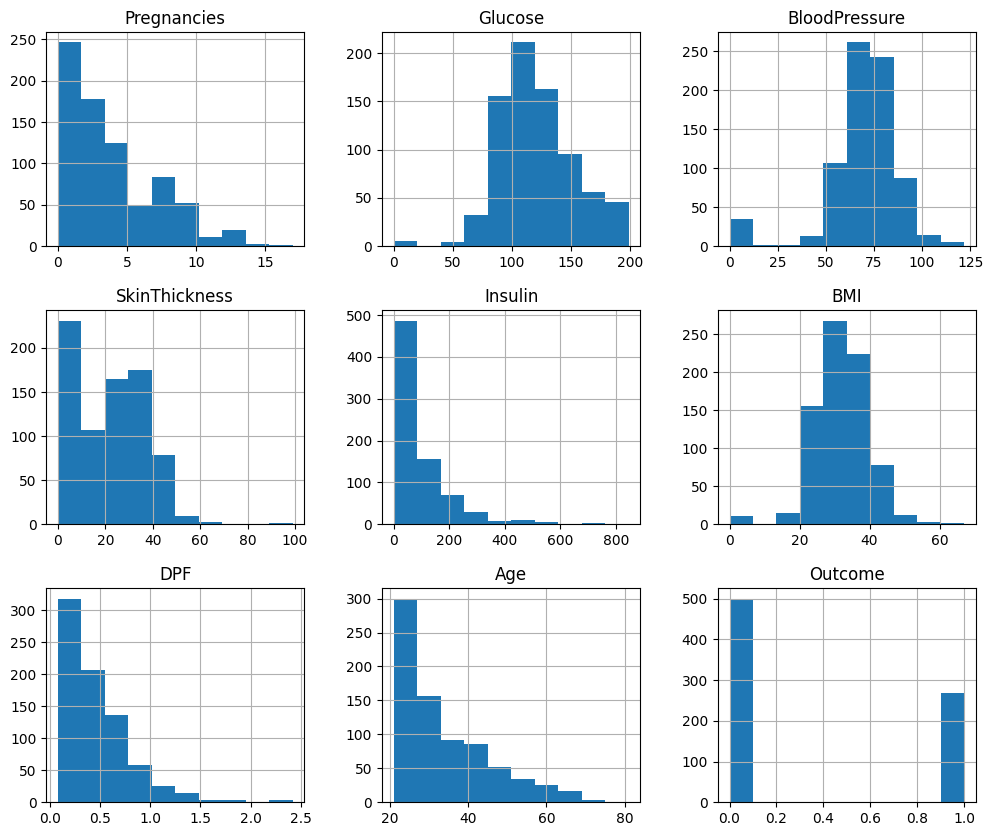

In [23]:
df.hist(figsize=(12,10))
plt.show()

👉 Nhận xét:
- Glucose lệch phải  
- BMI khá chuẩn  
- Insulin có nhiều giá trị bất thường  

### 3.4 Phân tích Glucose theo WHO

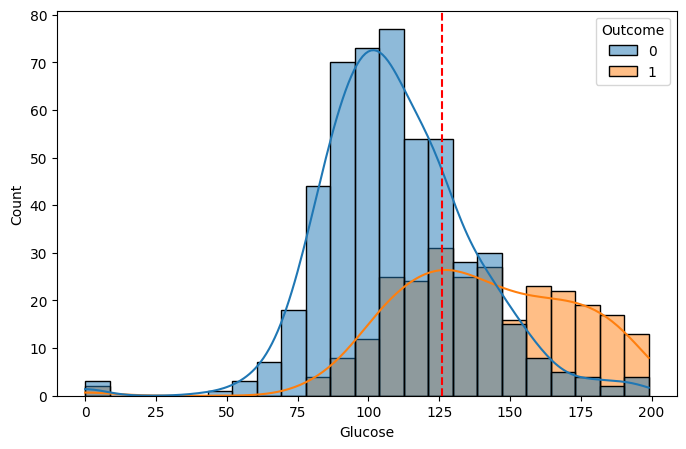

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.axvline(126, color='red', linestyle='--')
plt.show()

👉 Nhận xét:
- Người bệnh tập trung vùng Glucose cao  

### 3.5 Phân tích đa biến

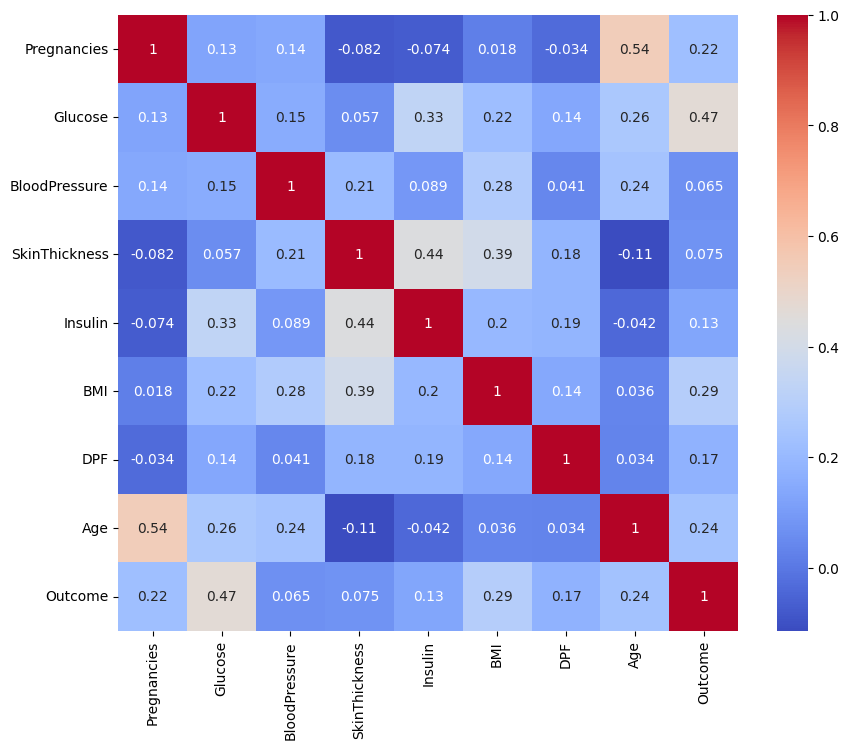

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

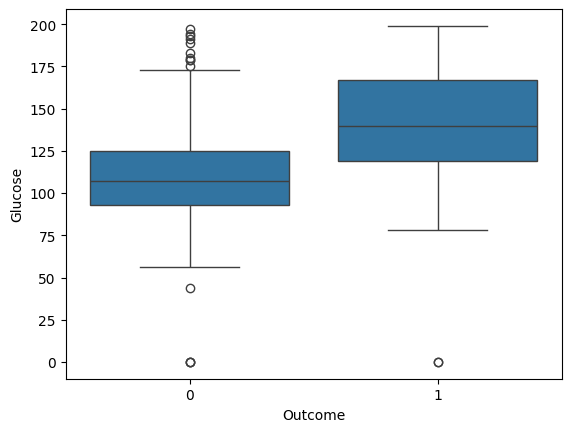

In [26]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

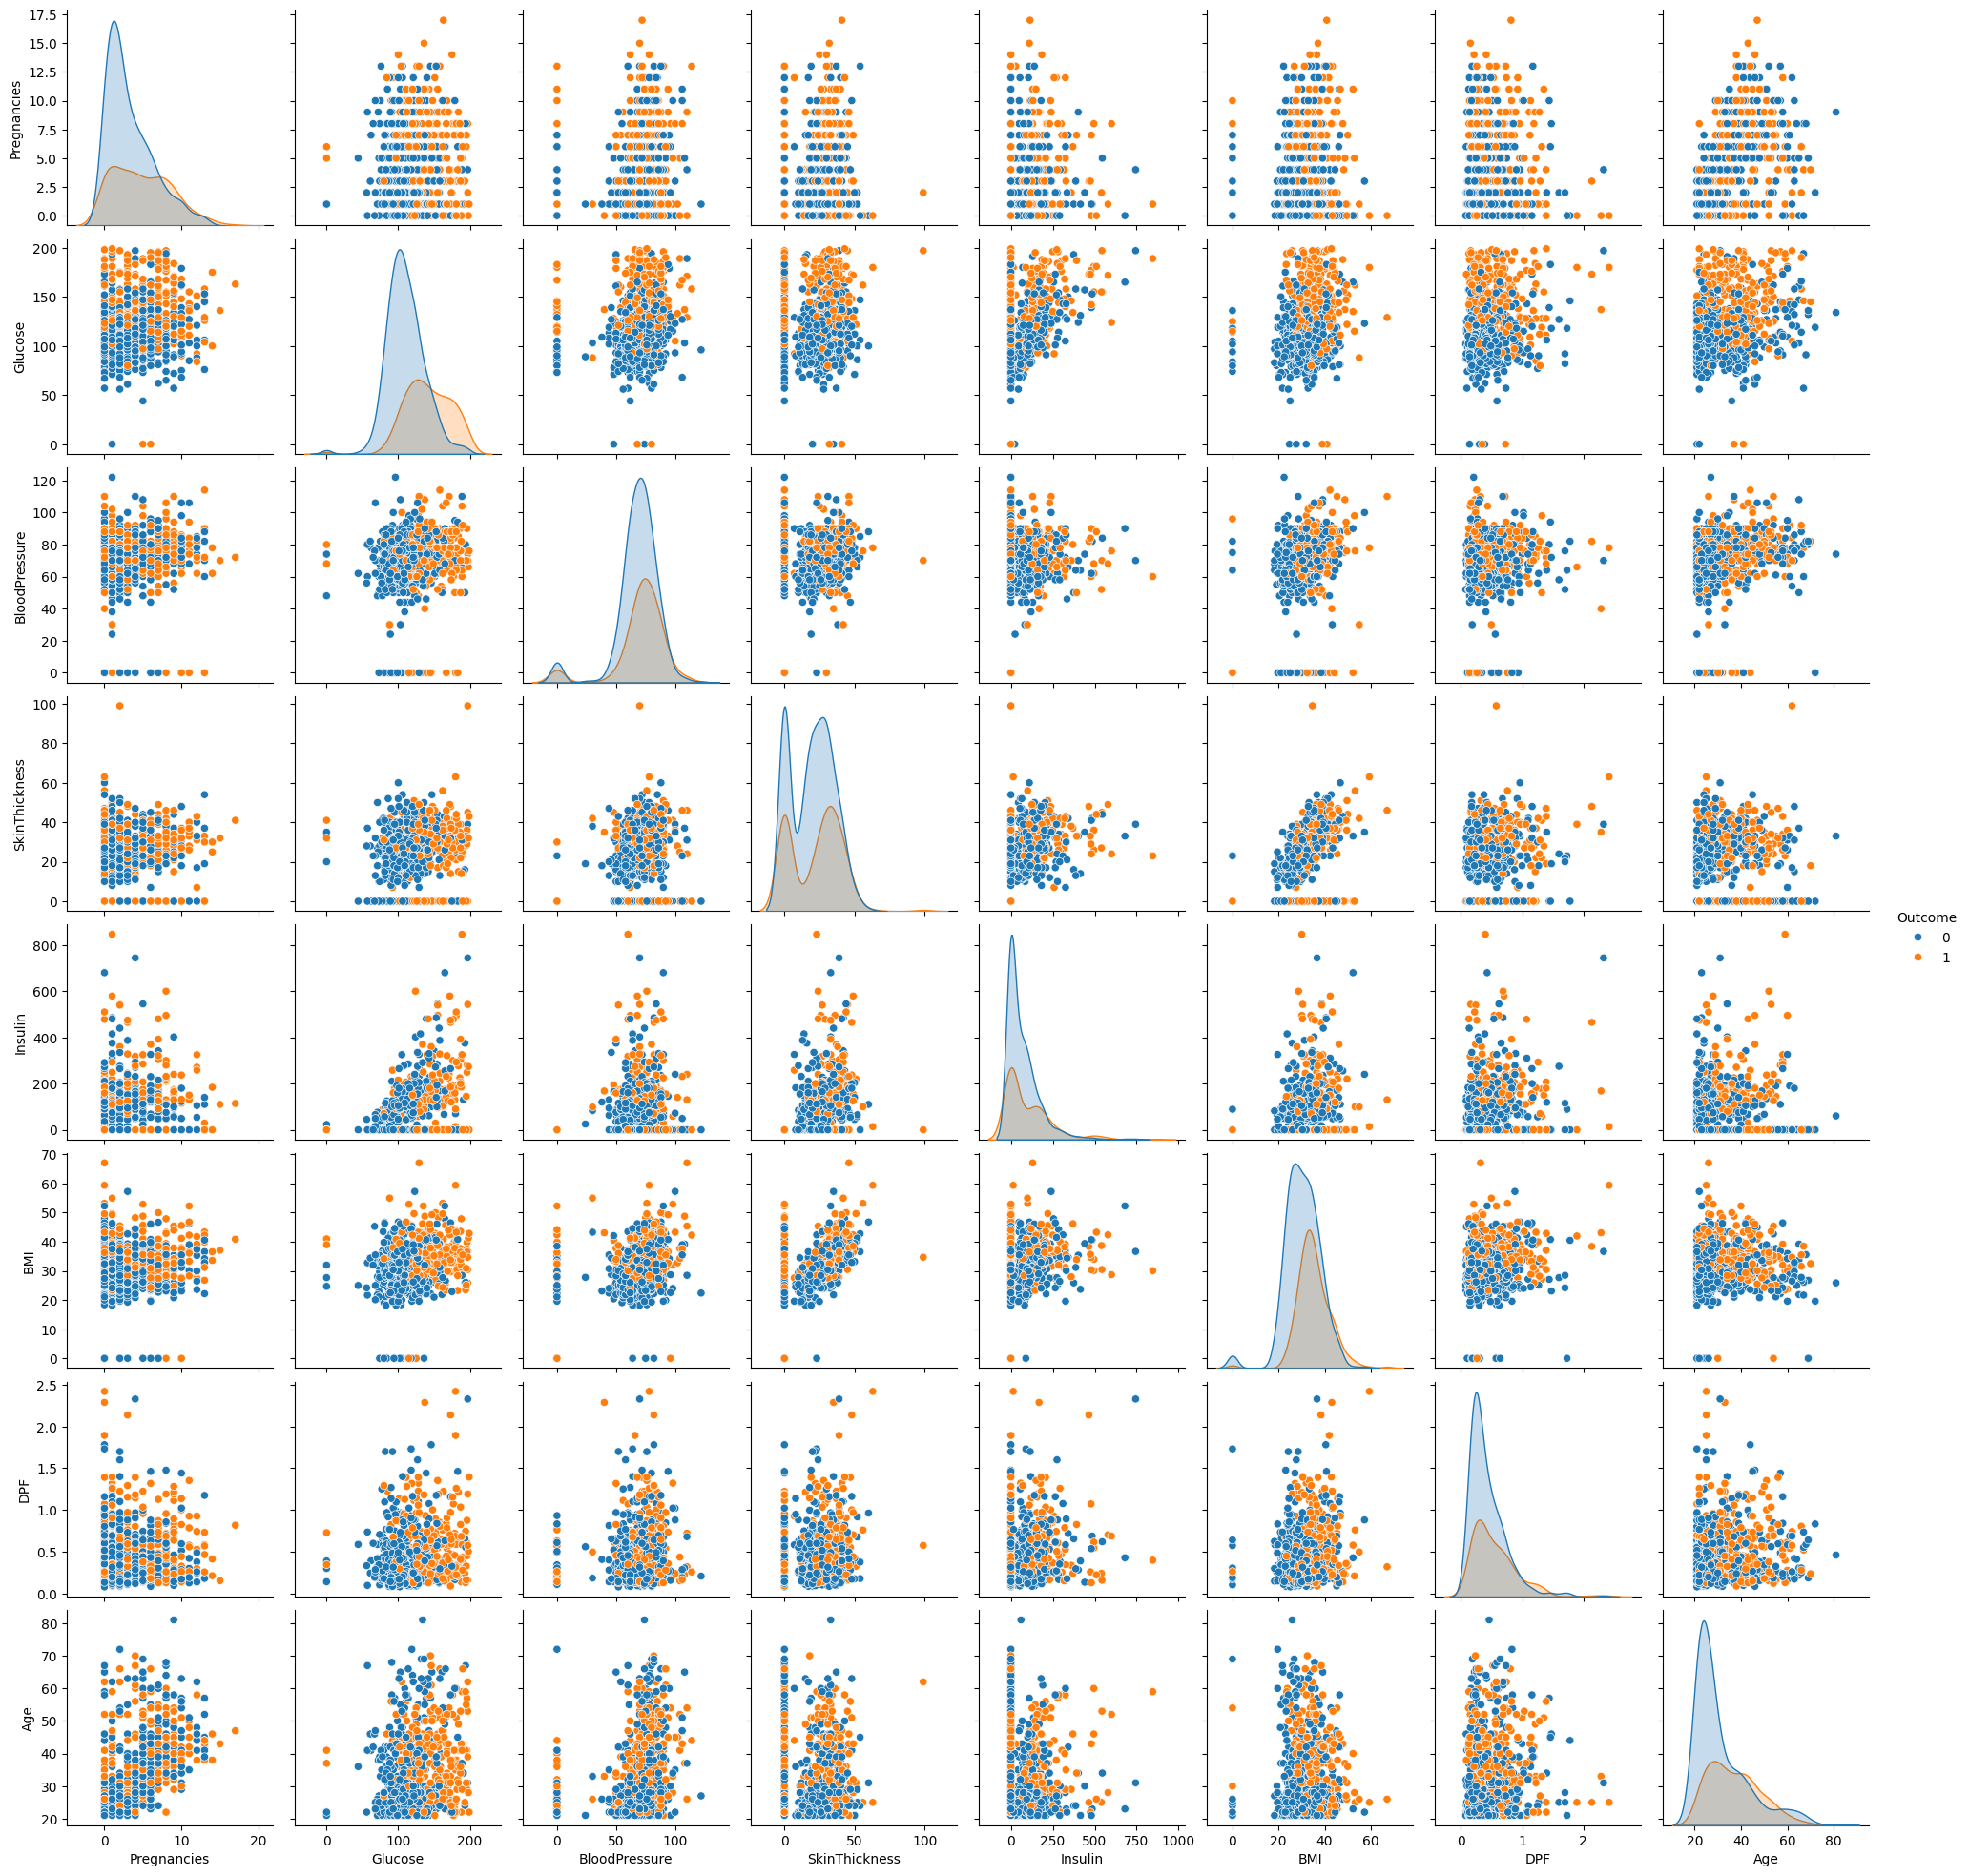

In [12]:
sns.pairplot(df, hue='Outcome')

### 3.6 Phát hiện ngoại lệ

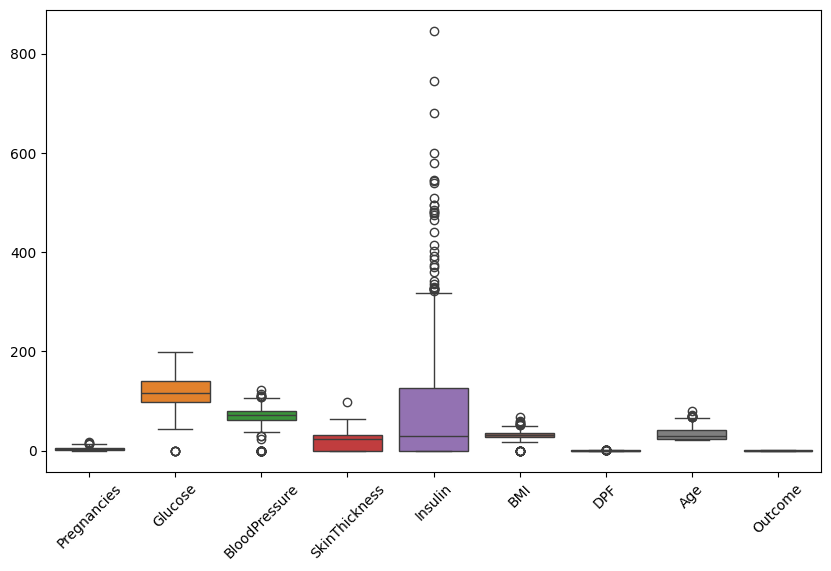

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

## 4. Tiền xử lý dữ liệu

In [14]:
df[invalid_cols] = df[invalid_cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Huấn luyện mô hình

In [15]:
mlp = MLPClassifier(hidden_layer_sizes=(12,8), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

## 6. Đánh giá mô hình

In [16]:
print("MLP:")
print(classification_report(y_test, mlp.predict(X_test_scaled)))

print("Logistic:")
print(classification_report(y_test, log_reg.predict(X_test_scaled)))

MLP:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

Logistic:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



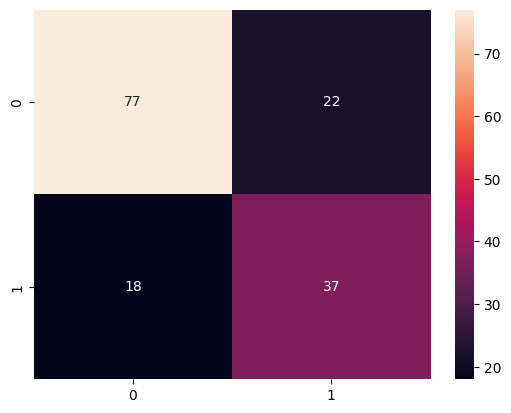

In [17]:
cm = confusion_matrix(y_test, mlp.predict(X_test_scaled))

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

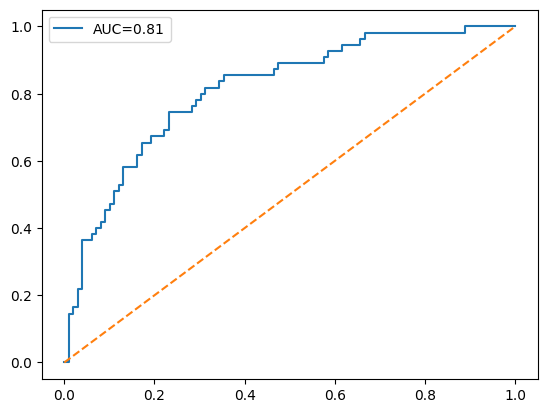

In [18]:
y_score = mlp.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

## 7. Kết luận

- MLP đạt AUC ~ 0.76  
- Glucose là yếu tố quan trọng nhất  
- Có thể áp dụng trong thực tế  

## 8. Hạn chế
- Thiếu dữ liệu  
- Chưa có HbA1c  

## 9. Hướng phát triển
- Thử mô hình khác  
- Xây dựng ứng dụng thực tế  